In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- BƯỚC 1: ĐỌC DỮ LIỆU ĐÃ XỬ LÝ ---
df_train = pd.read_csv('train_preprocessed.csv')
df_test = pd.read_csv('test_preprocessed.csv')

# Tách X (đầu vào) và y (đầu ra) cho tập Train
X_train = df_train.drop('outcome', axis=1)
y_train = df_train['outcome']

# Tách X (đầu vào) và y (đầu ra) cho tập Test
X_test = df_test.drop('outcome', axis=1)
y_test = df_test['outcome']

print(f"Đã tải xong: Train ({X_train.shape[0]} dòng), Test ({X_test.shape[0]} dòng)")

Đã tải xong: Train (80000 dòng), Test (20000 dòng)


In [ ]:
# --- BƯỚC 2: KHỞI TẠO VÀ HUẤN LUYỆN ---
# multi_class='multinomial' giúp xử lý 3 nhãn (0, 1, 2)
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# --- BƯỚC 3: DỰ ĐOÁN VÀ ĐÁNH GIÁ ---
y_pred = model.predict(X_test)

# Tính Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- KẾT QUẢ ---")
print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%")

# Báo cáo chi tiết (Precision, Recall, F1)
# Note: Bạn có thể thay target_names bằng list nhãn thực tế nếu còn nhớ mapping
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- KẾT QUẢ ---
Độ chính xác (Accuracy): 76.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79     11029
           1       0.76      0.68      0.72      8971

    accuracy                           0.76     20000
   macro avg       0.76      0.75      0.76     20000
weighted avg       0.76      0.76      0.76     20000



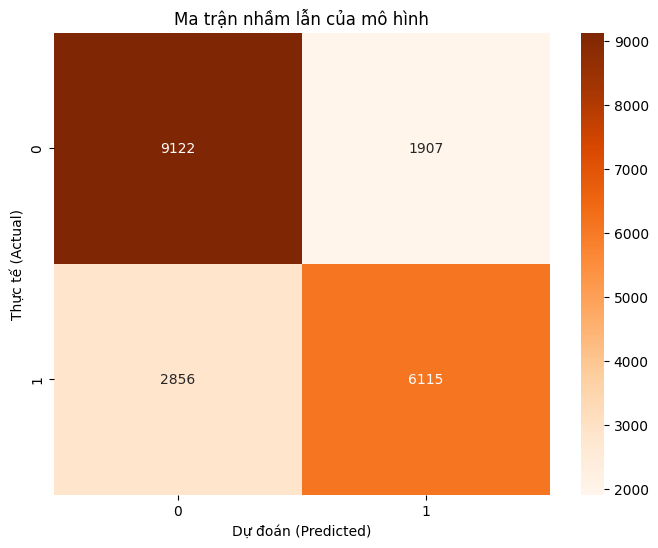

In [3]:
# --- BƯỚC 4: VẼ CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Ma trận nhầm lẫn của mô hình')
plt.show()

In [4]:
# Chọn dòng đầu tiên của tập Test (index = 0)
sample_index = 100
X_sample = X_test.iloc[[sample_index]] # Dùng [[]] để giữ định dạng DataFrame
y_actual = y_test.iloc[sample_index]

# Dự đoán nhãn (0, 1 hoặc 2)
prediction = model.predict(X_sample)

# Dự đoán xác suất (để xem mô hình tự tin bao nhiêu %)
probabilities = model.predict_proba(X_sample)

print(f"--- KẾT QUẢ TEST DÒNG {sample_index} ---")
print(f"Dự đoán của mô hình: {prediction[0]} (Xác suất: {probabilities.max()*100:.2f}%)")
print(f"Thực tế nhãn là: {y_actual}")

--- KẾT QUẢ TEST DÒNG 100 ---
Dự đoán của mô hình: 0 (Xác suất: 79.37%)
Thực tế nhãn là: 0
